In [2]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Dataset structure
df.info()

# Statistical summary
df.describe()

# Check column names
df.columns

# Dataset shape
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       289 non-null    int64  
 1   sex       289 non-null    int64  
 2   cp        289 non-null    int64  
 3   trtbps    289 non-null    int64  
 4   chol      289 non-null    int64  
 5   fbs       289 non-null    int64  
 6   restecg   289 non-null    int64  
 7   thalachh  289 non-null    int64  
 8   exng      289 non-null    int64  
 9   oldpeak   289 non-null    float64
 10  slp       289 non-null    int64  
 11  caa       289 non-null    int64  
 12  thall     289 non-null    int64  
 13  output    289 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 31.7 KB


(289, 14)

In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [5]:
df.fillna(df.median(), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)
df.duplicated().sum()
df = df.drop_duplicates()

In [6]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,54.065972,0.677083,1.017361,131.354167,248.215278,0.145833,0.513889,150.152778,0.319444,1.011111,1.416667,0.701389,2.315972,0.569444
std,9.099096,0.468405,1.027349,17.544555,51.505646,0.353553,0.514407,22.899970,0.467073,1.133900,0.613438,1.005766,0.596875,0.496016
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,212.000000,0.000000,0.000000,135.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,243.000000,0.000000,1.000000,154.000000,0.000000,0.650000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,276.250000,0.000000,1.000000,167.250000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

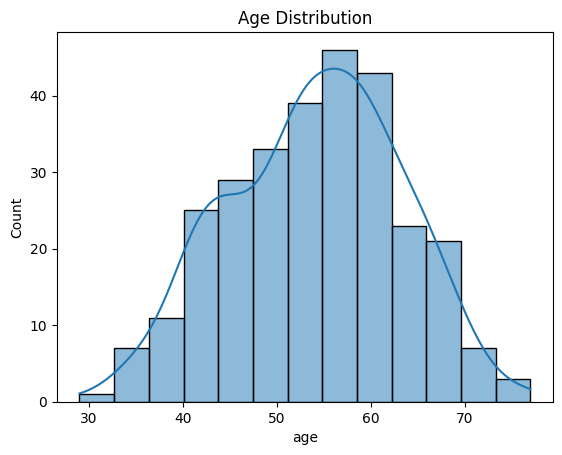

In [7]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

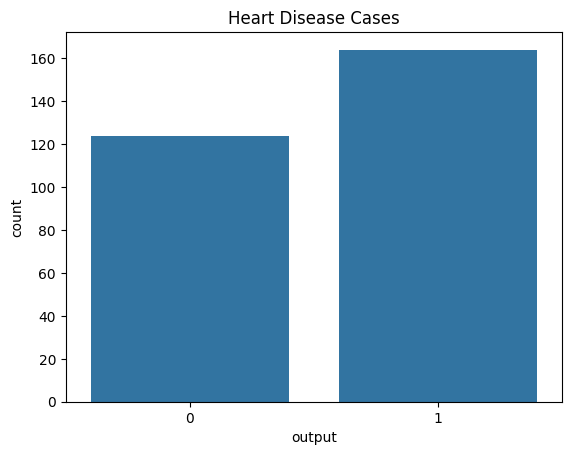

In [8]:
sns.countplot(x='output', data=df)
plt.title("Heart Disease Cases")
plt.show()

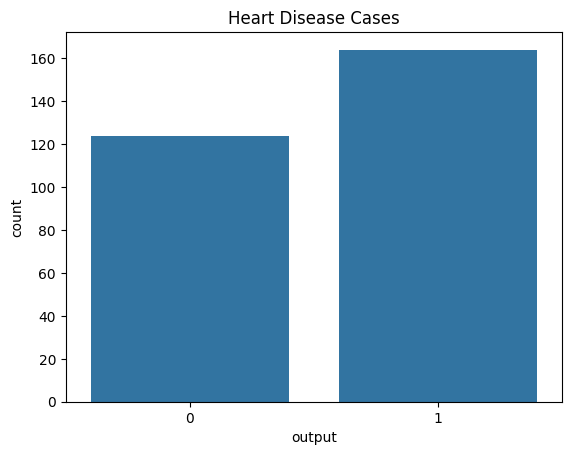

In [9]:
sns.countplot(x='output', data=df)
plt.title("Heart Disease Cases")
plt.show()

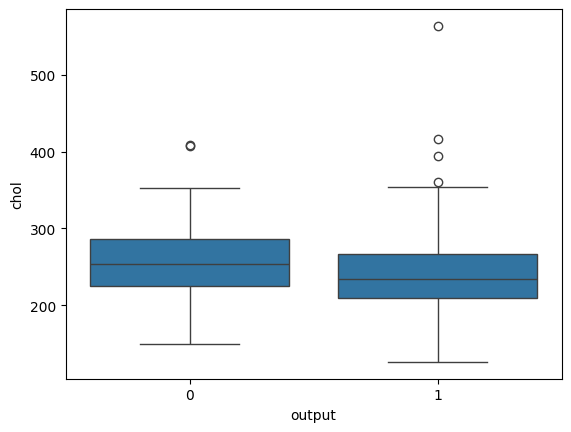

In [10]:
sns.boxplot(x='output', y='chol', data=df)
plt.show()

In [11]:
y = df['output']

# Features
X = df.drop(columns=['output'])

X.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [19]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_test, y_pred, name):
    print(f"{name}")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("-" * 40)

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")

Linear Regression
R2 Score: 0.41655168171182155
MSE: 0.14516832414007294
RMSE: 0.38100961161114155
----------------------------------------
Ridge Regression
R2 Score: 0.41724763384849317
MSE: 0.14499516363519954
RMSE: 0.3807823047821413
----------------------------------------
Lasso Regression
R2 Score: 0.3368161801389601
MSE: 0.16500738918659047
RMSE: 0.40621101558991535
----------------------------------------


In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='r2')

print("Cross-validation scores:", cv_scores)
print("Average CV score:", np.mean(cv_scores))

Cross-validation scores: [0.         0.         0.10895572 0.         0.        ]
Average CV score: 0.021791143115073595


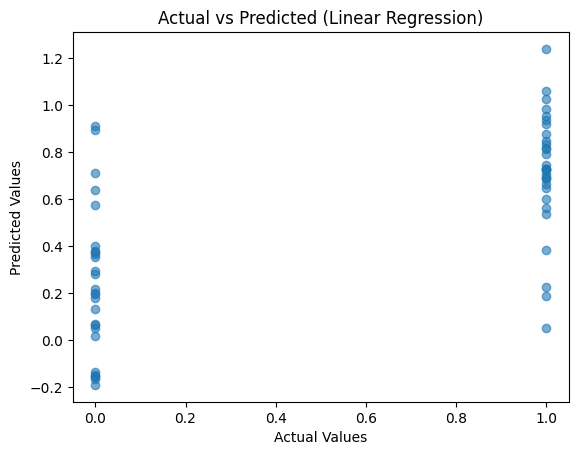

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

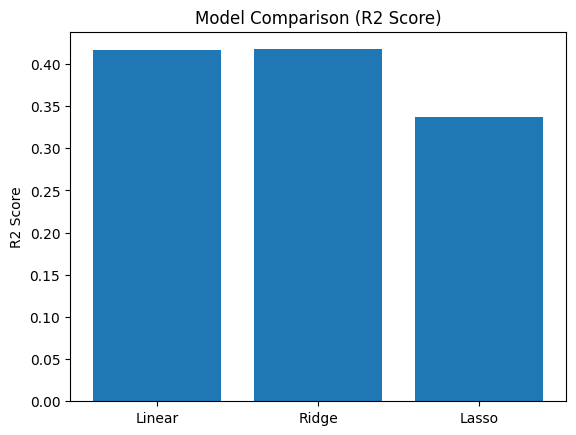

In [23]:
models = ['Linear', 'Ridge', 'Lasso']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()